# 04 -  Forecasting

### Credit Card Fraud Risk Detection & Transaction Risk Scoring

**Author: Corbin Couger**

Objective - Forecast when the next fraud spike is coming.

Dataset - [Kaggle Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

Outline:

1. Time Series Preperation
2. Forecast with ARIMA Model
3. Forecast with Prophet Model
4. Model Comparison

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
import pickle

In [94]:
df = pd.read_csv('../data/raw/creditcard.csv') # want the original dataset because I want to forecast with all of the data I have
df = df.drop_duplicates().reset_index(drop=True)

### 1. Time Series Preparation

In [95]:
# similar in the preprocessing, I want to create an hourly dataset of all 48 hours in the dataset
df['Hour'] = (df['Time'] / 3600).astype(int)

hourly = df.groupby('Hour').agg(
    total_transactions = ('Class', 'count'),
    fraud_count = ('Class', 'sum'),
    fraud_rate = ('Class', 'mean')
).reset_index()

hourly.head()

,Hour,total_transactions,fraud_count,fraud_rate
0,0,3931,2,0.000509
1,1,2213,2,0.000904
2,2,1573,21,0.013350
3,3,1818,13,0.007151
4,4,1082,6,0.005545


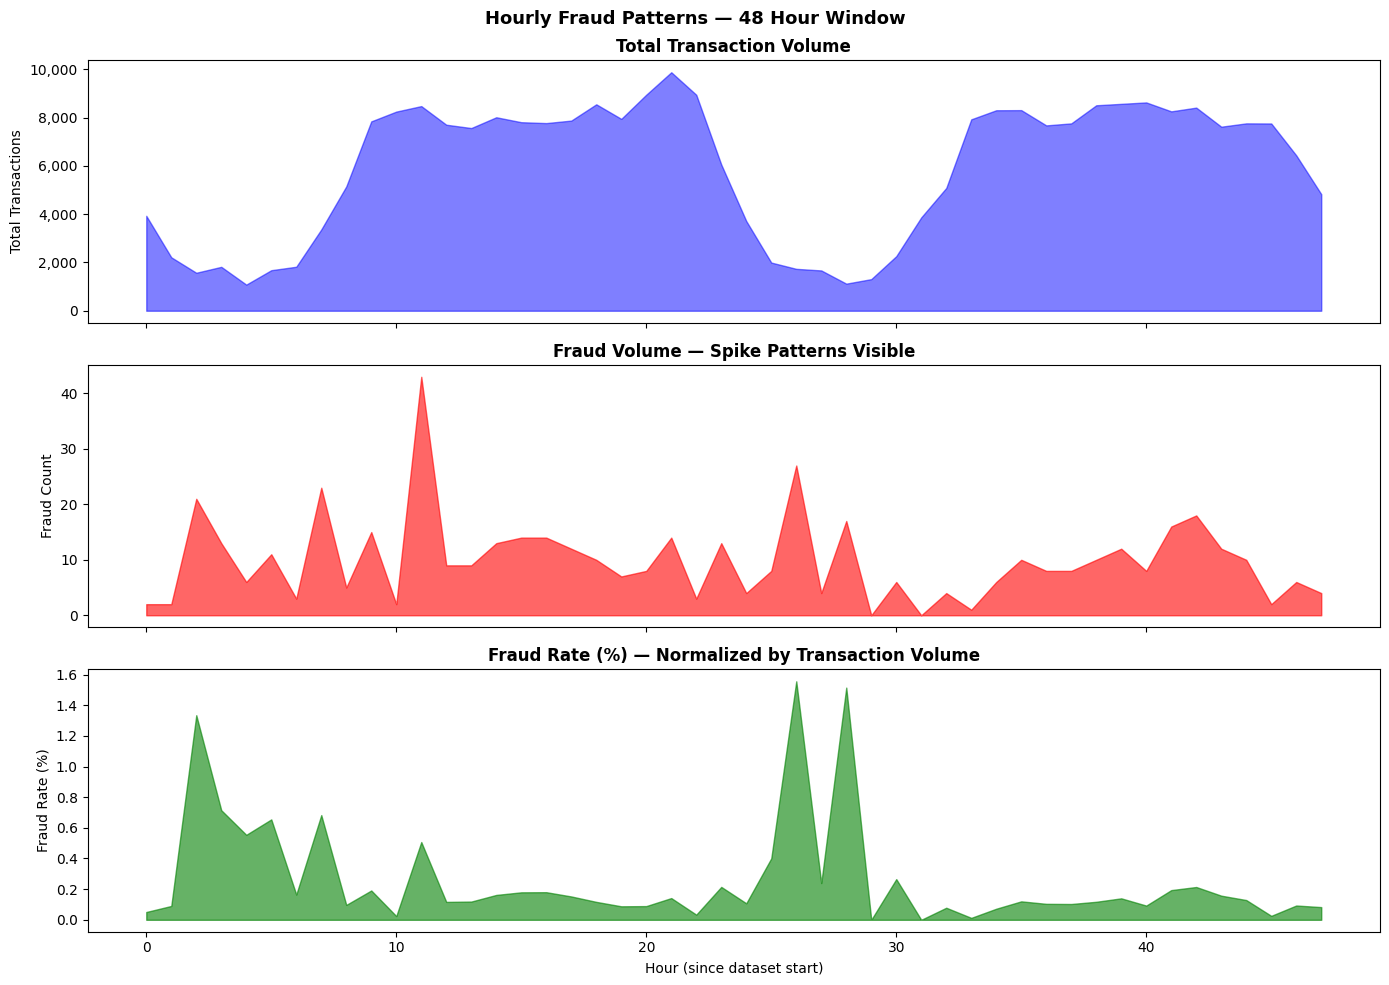

In [96]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Total transactions
axes[0].fill_between(hourly['Hour'], hourly['total_transactions'],
                     color='blue', alpha=0.5)
axes[0].set_ylabel('Total Transactions')
axes[0].set_title('Total Transaction Volume', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Fraud count
axes[1].fill_between(hourly['Hour'], hourly['fraud_count'],
                     color='red', alpha=0.6)
axes[1].set_ylabel('Fraud Count')
axes[1].set_title('Fraud Volume — Spike Patterns Visible', fontweight='bold')

# Fraud rate
axes[2].fill_between(hourly['Hour'], hourly['fraud_rate'] * 100,
                     color='green', alpha=0.6)
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xlabel('Hour (since dataset start)')
axes[2].set_title('Fraud Rate (%) — Normalized by Transaction Volume', fontweight='bold')

plt.suptitle('Hourly Fraud Patterns — 48 Hour Window',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_fraud_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

##### **Notes:**

The original data is now transformed into a time-series format with the data being sequential hourly formatted.

Next up,

### 2. ARIMA Forecasting

Before building the model, I need to do a quick test that is required for ARIMA models. This is called the Stationarity test which tests if the dataset is stable. ARIMA relys on stability to make accurate predictions, therefore the data must be stationary. A common test for stationarity is the ADF test.

In [97]:
fraud_series = hourly['fraud_count'].values
adf_result = adfuller(fraud_series)

print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'ADF p-value: {adf_result[1]:.4f}')
print(f'ADF Critical: {adf_result[4]['5%']:.4f}')

# testing at 5% confidence

print('Series is Stationary' if adf_result[1] < .05 else 'Series needs differencing')

ADF Statistic: -4.3438
ADF p-value: 0.0004
ADF Critical: -2.9268
Series is Stationary


##### **Notes:**

The data passes the ADF test which leads me to my next look at the data. I will build ACF & PACF plots to determine the p and q for ARIMA modeling.

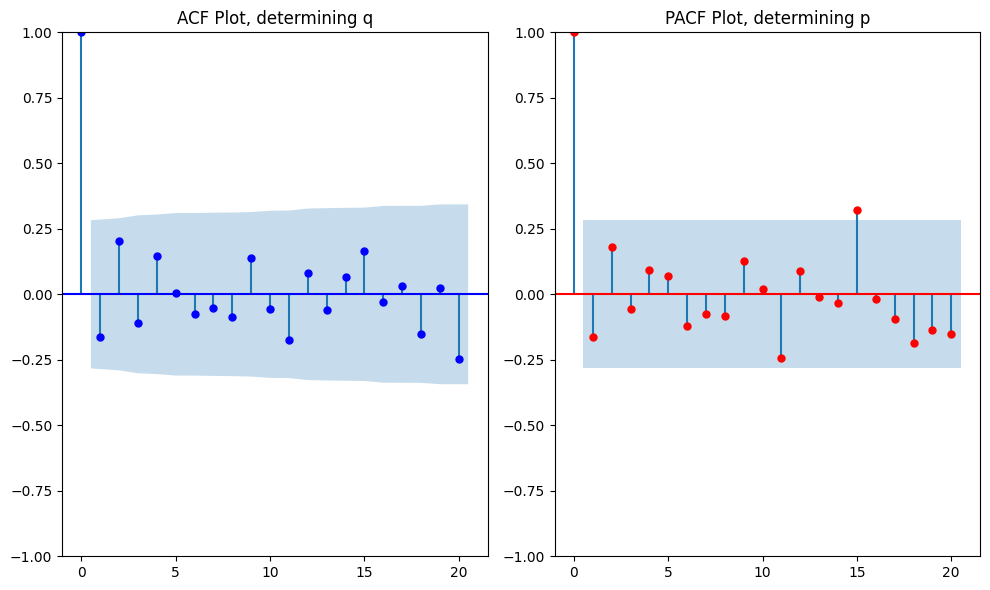

In [98]:
fig, axes = plt.subplots(1, 2, figsize = (10, 6))

plot_acf(fraud_series, lags = 20, ax=axes[0], color = 'blue')
plot_pacf(fraud_series, lags = 20, ax=axes[1], color = 'red')

axes[0].set_title('ACF Plot, determining q')
axes[1].set_title('PACF Plot, determining p')
plt.tight_layout()
plt.show()

##### **Notes:**

Both the plots above help determine 2 of the 3 parameters I will feed into my ARIMA model. The left (ACF Plot) helps understand what I should utilize for my parameter q. The right (PACF Plot) determines parameter p. Since both plots drop off right after the 0 lag, I will use 0 for both p and q. d, the 3rd parameter, will also be 0 as the data was stationary.

In [99]:
# since order must be preserved in a time series, I will split my data using the last 12 hours. This is 25% of the dataset (12 out of 48 hours)
train_size = len(hourly) - 12

arima_train = fraud_series[:train_size]
arima_test = fraud_series[train_size:]

print(f'Train Size: {len(arima_train)}')
print(f'Test Size: {len(arima_test)}')

Train Size: 36
Test Size: 12


In [100]:
# fitting the data to the model
arima_model = ARIMA(arima_train, order = (0,0,0))
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   36
Model:                          ARIMA   Log Likelihood                -128.069
Date:                Mon, 22 Jun 2026   AIC                            260.137
Time:                        11:39:31   BIC                            263.304
Sample:                             0   HQIC                           261.242
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.9722      2.012      4.958      0.000       6.030      13.915
sigma2        72.0299     13.565      5.310      0.000      45.444      98.616
Ljung-Box (L1) (Q):                   1.91   Jarque-

In [101]:
# ARIMA actual forecast

arima_forecast = arima_fit.forecast(steps=12) # 12 being the test size
arima_forecast_ci = arima_fit.get_forecast(steps=12).conf_int() # confidence intervals for the forecasts

# need to ensure there are no negative forecasts

arima_forecast = np.clip(arima_forecast, 0, None)
arima_lower = np.clip(arima_forecast_ci[:,0], 0, None)
arima_upper = arima_forecast_ci[:,1]

forecast_hours = hourly['Hour'].values[train_size:]

In [102]:
# comparing forecast and actual

for i, (actual, pred) in enumerate(zip(arima_test, arima_forecast)):
    print(f'Hour {forecast_hours[i]} -> Actual: {actual:.5f} vs. Forecast: {pred:.5f}')

Hour 36 -> Actual: 8.00000 vs. Forecast: 9.97222
Hour 37 -> Actual: 8.00000 vs. Forecast: 9.97222
Hour 38 -> Actual: 10.00000 vs. Forecast: 9.97222
Hour 39 -> Actual: 12.00000 vs. Forecast: 9.97222
Hour 40 -> Actual: 8.00000 vs. Forecast: 9.97222
Hour 41 -> Actual: 16.00000 vs. Forecast: 9.97222
Hour 42 -> Actual: 18.00000 vs. Forecast: 9.97222
Hour 43 -> Actual: 12.00000 vs. Forecast: 9.97222
Hour 44 -> Actual: 10.00000 vs. Forecast: 9.97222
Hour 45 -> Actual: 2.00000 vs. Forecast: 9.97222
Hour 46 -> Actual: 6.00000 vs. Forecast: 9.97222
Hour 47 -> Actual: 4.00000 vs. Forecast: 9.97222


In [103]:
# ARIMA model evaluation

arima_mae = mean_absolute_error(arima_test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(arima_test, arima_forecast))

print(f'ARIMA MAE: {arima_mae}')
print(f'ARIMA RMSE: {arima_rmse:.4f}')

ARIMA MAE: 3.5
ARIMA RMSE: 4.4317


##### **Notes:**

The ARIMA Model looks somewhat promising. The results of the model tell me that there is a 35% average error rate (3 to 4 fraud transactions per hour). I also noticed the Forecasts all looked the same.

Being that the dataset only contains 48 hours worth of data with few fraud transactions, the model is reverting back to the mean. In an environment where there is months of hourly data, the ARIMA model would better capture a meaningful trend. This is not an issue with this model persay, just a **limitation** I observed. ARIMA models in production will need plenty of historical data.

### 3. Prophet Model Forecasting

In [105]:
prophet_df = pd.DataFrame({
    'ds': pd.date_range(start = '2024-01-01', periods = len(hourly), freq='h'),
    'y': hourly['fraud_count'].values
})

prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

prophet_model = Prophet(
    interval_width= .95,
    daily_seasonality= False,
    weekly_seasonality= False,
    yearly_seasonality= False,
    changepoint_prior_scale= .5
)

prophet_model.fit(prophet_train)

11:43:08 - cmdstanpy - INFO - Chain [1] start processing
11:43:09 - cmdstanpy - INFO - Chain [1] done processing


##### **Notes:**

I wanted to note I built the model with zero seasonality since it is just 2 days worth of data, but in a production environment, these elements would be explored

In [ ]:
# forecasting with the prophet model

prophet_future = prophet_model.make_future_dataframe(periods=12, freq='h')
prophet_forecast = prophet_model.predict(prophet_future)

# using this to get the test predictions from the model
prophet_test_preds = prophet_forecast.tail(12)['yhat'].values
prophet_test_preds = np.clip(prophet_test_preds, 0, None) # like ARIMA, no predictions can be negative

prophet_mae = mean_absolute_error(arima_test, prophet_test_preds)
prophet_rmse = np.sqrt(mean_squared_error(arima_test, prophet_test_preds)) # using ARIMA test data here as it is the same data, just in the correct series format the predictions are in

print(f'Prophet MAE: {prophet_mae}')
print(f'Prophet RMSE: {prophet_rmse}')

Prophet MAE: 6.041127386875231
Prophet RMSE: 7.298830757091711



### 4. Model Comparison & Saving Models

The prophet model performed worse than the ARIMA model meaning the ARIMA model comes out on top.

As noted in the ARIMA section, the model resorted to the mean which means the forecasts will have consistent errors across the future. *For a production environment*, the forecasting model will need more data.



In [115]:
os.makedirs('../models', exist_ok=True)

with open('../models/prophet_model.pkl', 'wb') as f:
    pickle.dump(prophet_model, f)

arima_fit.save('../models/arima_model.pkl')

hourly.to_csv('../data/processed/hourly_fraud_series.csv', index = False)


---
##### Summary of Notebook

Trained Models: ARIMA, Prophet
Evaluated On: MAE, RMSE
Selected Model: ARIMA

This Notebook was intended to predict the future data to help fuel the Keras Neural Network model to do its thing.

Value for Business:
Predicting the future for fraud allows proactivity to reduce the time before fraud attacks peak.

---

Next up, 'app.py' (Streamlit dashboard)